# **Complaint Resolution Bottleneck Analysis**
This is an operational analysis of 9.4M+ consumer financial complaints (2023–2025) exploring agency routing delays and company compliance.

**1. Data Ingestion & Memory Management**

Streaming 9.4M+ records in chunks to prevent memory crashes, dropping heavy narrative text, and downcasting text columns to `category` dtypes.

In [15]:
import pandas as pd
import time

CFPB_CSV_URL = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"

target_cols = [
    'Complaint ID',
    'Date received',
    'Date sent to company',
    'Product',
    'Sub-product',
    'Issue',
    'Sub-issue',
    'Company',
    'State',
    'Submitted via',
    'Company response to consumer',
    'Timely response?'
]

start_time = time.time()
chunks = []
chunk_count = 0
retained_rows = 0

print("Loading CFPB complaints received from 2023 to 2025...")

# Read the large CSV in smaller chunks
for chunk in pd.read_csv(
    CFPB_CSV_URL,
    compression='zip',
    usecols=target_cols,
    chunksize=150_000,
    low_memory=False
):
    chunk_count += 1
    chunk['Date received'] = pd.to_datetime(
        chunk['Date received'], errors='coerce'
    )

    # Keep complaints received within the selected date range
    mask = (
        (chunk['Date received'] >= '2023-01-01') &
        (chunk['Date received'] < '2026-01-01')
    )
    filtered_chunk = chunk.loc[mask].copy()

    if not filtered_chunk.empty:
        chunks.append(filtered_chunk)
        retained_rows += len(filtered_chunk)

    if chunk_count % 5 == 0:
        print(
            f"Chunks processed: {chunk_count:,} | "
            f"Rows retained: {retained_rows:,}"
        )

df = pd.concat(chunks, ignore_index=True)

df['Date sent to company'] = pd.to_datetime(
    df['Date sent to company'], errors='coerce'
)

# Convert repeated text values to categories to save memory
categorical_cols = [
    'Product', 'Sub-product', 'Issue', 'Sub-issue',
    'Company', 'State', 'Submitted via',
    'Company response to consumer', 'Timely response?'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

elapsed_time = (time.time() - start_time) / 60
mem_usage_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

print("\nData loading complete")
print(f"Chunks processed: {chunk_count:,}")
print(f"Complaints retained: {len(df):,}")
print(f"Date range: {df['Date received'].min():%Y-%m-%d} to "
      f"{df['Date received'].max():%Y-%m-%d}")
print(f"DataFrame memory usage: {mem_usage_mb:,.2f} MB")
print(f"Elapsed time: {elapsed_time:.2f} minutes")

Loading CFPB complaints received from 2023 to 2025...
Chunks processed: 5 | Rows retained: 204,341
Chunks processed: 10 | Rows retained: 954,341
Chunks processed: 15 | Rows retained: 1,704,341
Chunks processed: 20 | Rows retained: 2,454,341
Chunks processed: 25 | Rows retained: 3,204,341
Chunks processed: 30 | Rows retained: 3,954,341
Chunks processed: 35 | Rows retained: 4,704,341
Chunks processed: 40 | Rows retained: 5,454,341
Chunks processed: 45 | Rows retained: 6,204,341
Chunks processed: 50 | Rows retained: 6,954,341
Chunks processed: 55 | Rows retained: 7,704,341
Chunks processed: 60 | Rows retained: 8,454,341
Chunks processed: 65 | Rows retained: 9,204,341
Chunks processed: 70 | Rows retained: 9,252,553
Chunks processed: 75 | Rows retained: 9,252,553
Chunks processed: 80 | Rows retained: 9,252,553
Chunks processed: 85 | Rows retained: 9,252,553
Chunks processed: 90 | Rows retained: 9,252,553
Chunks processed: 95 | Rows retained: 9,252,553
Chunks processed: 100 | Rows retained: 

**2. Data Quality Audit**

Checking for duplicate complaint IDs, missing values, and date inconsistencies.

*Note: Some complaints received in late 2025 were sent to companies in 2026. These records are retained because the analysis is based on the date received.*


In [16]:
# 1. Check complaint ID uniqueness

total_rows = len(df)
unique_ids = df['Complaint ID'].nunique()
duplicate_ids = total_rows - unique_ids

print("\n1. RECORD UNIQUENESS")
print(f"Total rows: {total_rows:,}")
print(f"Unique Complaint IDs: {unique_ids:,}")
print(f"Duplicate IDs: {duplicate_ids:,}")


# 2. Check dates and routing lag

missing_received_dates = df['Date received'].isna().sum()
missing_sent_dates = df['Date sent to company'].isna().sum()

transit_days = (
    df['Date sent to company'] - df['Date received']
).dt.days

negative_transit = (transit_days < 0).sum()
zero_transit = (transit_days == 0).sum()
positive_transit = (transit_days > 0).sum()

sent_in_2026 = df['Date sent to company'] >= '2026-01-01'
received_late_2025 = df['Date received'] >= '2025-11-01'

sent_2026_count = sent_in_2026.sum()
sent_2026_late_2025 = (
    sent_in_2026 & received_late_2025
).sum()

print("\n2. DATE CHECKS")
print(f"Missing received dates: {missing_received_dates:,}")
print(f"Missing sent dates: {missing_sent_dates:,}")
print(f"Received date range: {df['Date received'].min().date()} to {df['Date received'].max().date()}")
print(f"Sent date range: {df['Date sent to company'].min().date()} to {df['Date sent to company'].max().date()}")
print(f"Sent in 2026 or later: {sent_2026_count:,}")
print(f"Sent in 2026+, received from Nov 2025 onward: {sent_2026_late_2025:,}")
print(f"Negative routing lag: {negative_transit:,}")
print(f"Same-day routing: {zero_transit:,} ({zero_transit / total_rows * 100:.2f}%)")
print(f"Positive routing lag: {positive_transit:,} ({positive_transit / total_rows * 100:.2f}%)")


# 3. Check missing values

print("\n3. MISSING VALUES")

missing_summary = pd.DataFrame({
    'Missing Values': df.isna().sum(),
    'Missing %': df.isna().sum() / total_rows * 100
}).sort_values('Missing Values', ascending=False)

print(
    missing_summary[missing_summary['Missing Values'] > 0]
    .to_string()
)


# 4. Check response categories

print("\n4. RESPONSE DISTRIBUTIONS")

print("\nTimely response:")
timely_response = (
    df['Timely response?']
    .value_counts(dropna=False)
    .rename_axis('Response')
    .reset_index(name='Count')
)

timely_response['Percentage'] = (
    timely_response['Count'] / total_rows * 100
)

print(timely_response.to_string(index=False, formatters={
    'Percentage': '{:.2f}%'.format
}))

print("\nCompany response to consumer:")
company_response = (
    df['Company response to consumer']
    .value_counts(dropna=False)
    .rename_axis('Response')
    .reset_index(name='Count')
)

company_response['Percentage'] = (
    company_response['Count'] / total_rows * 100
)

print(company_response.to_string(index=False, formatters={
    'Percentage': '{:.2f}%'.format
}))


1. RECORD UNIQUENESS
Total rows: 9,469,268
Unique Complaint IDs: 9,469,268
Duplicate IDs: 0

2. DATE CHECKS
Missing received dates: 0
Missing sent dates: 0
Received date range: 2023-01-01 to 2025-12-31
Sent date range: 2023-01-01 to 2026-09-15
Sent in 2026 or later: 5,785
Sent in 2026+, received from Nov 2025 onward: 5,424
Negative routing lag: 0
Same-day routing: 9,119,013 (96.30%)
Positive routing lag: 350,255 (3.70%)

3. MISSING VALUES
                              Missing Values  Missing %
Sub-issue                             193762   2.046219
State                                  17967   0.189740
Company response to consumer              19   0.000201
Issue                                      6   0.000063
Sub-product                                5   0.000053

4. RESPONSE DISTRIBUTIONS

Timely response:
Response   Count Percentage
     Yes 9431475     99.60%
      No   37793      0.40%

Company response to consumer:
                       Response   Count Percentage
        C

**3. Cleaning and Feature Engineering**

Handle missing values, calculate routing time, and create a few features for analysis.


In [17]:
import numpy as np

# 1. Remove rows without a recorded company response
initial_rows = len(df)
df_clean = df.dropna(subset=['Company response to consumer']).copy()
dropped_rows = initial_rows - len(df_clean)

# 2. Fill missing categorical values
sparse_cols = ['Sub-issue', 'State', 'Sub-product', 'Issue']

for col in sparse_cols:
    if df_clean[col].dtype.name == 'category':
        if 'Unspecified' not in df_clean[col].cat.categories:
            df_clean[col] = df_clean[col].cat.add_categories('Unspecified')
    df_clean[col] = df_clean[col].fillna('Unspecified')

# 3. Calculate routing time in calendar days
df_clean['Transit_Days'] = (
    df_clean['Date sent to company'] - df_clean['Date received']
).dt.days

# Group routing time for easier comparison
transit_bins = [-1, 0, 2, 7, np.inf]
transit_labels = ['Same Day', '1-2 Days', '3-7 Days', '8+ Days']

df_clean['Transit_Bucket'] = pd.cut(
    df_clean['Transit_Days'],
    bins=transit_bins,
    labels=transit_labels
)

# 4. Extract year and month of complaint receipt
df_clean['Year'] = df_clean['Date received'].dt.year
df_clean['Year_Month'] = df_clean['Date received'].dt.to_period('M')

# 5. Flag complaints marked as untimely
df_clean['Is_Untimely'] = (
    df_clean['Timely response?'] == 'No'
).astype(int)

# 6. Group company response outcomes
outcome_mapping = {
    'Closed with explanation': 'Explanation',
    'Closed with non-monetary relief': 'Non-Monetary Relief',
    'Closed with monetary relief': 'Monetary Relief',
    'Closed with relief': 'Relief (Unspecified)',
    'Closed': 'Closed',
    'Untimely response': 'Administrative/Untimely',
    'In progress': 'Administrative/Open'
}

df_clean['Outcome_Class'] = (
    df_clean['Company response to consumer']
    .map(outcome_mapping)
)


# Check for response categories not covered by the mapping
print("Missing outcome classifications:", df_clean['Outcome_Class'].isna().sum())

# Check the main transformations
print("CLEANING SUMMARY")
print(f"Rows before cleaning: {initial_rows:,}")
print(f"Rows removed: {dropped_rows:,}")
print(f"Rows retained: {len(df_clean):,}")
print(f"Missing company responses: {df_clean['Company response to consumer'].isna().sum():,}")
print(f"Missing routing times: {df_clean['Transit_Days'].isna().sum():,}")
print(f"Same-day routing: {(df_clean['Transit_Days'] == 0).sum():,}")
print(f"Delayed routing: {(df_clean['Transit_Days'] > 0).sum():,}")
print(f"Memory usage: {df_clean.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")

# Use the cleaned dataset for the remaining analysis
del df

Missing outcome classifications: 0
CLEANING SUMMARY
Rows before cleaning: 9,469,268
Rows removed: 19
Rows retained: 9,469,249
Missing company responses: 0
Missing routing times: 0
Same-day routing: 9,118,994
Delayed routing: 350,255
Memory usage: 659.77 MB


In [18]:

# 1. Routing time distribution
print("Routing Time Distribution (%)")
print((df_clean['Transit_Bucket'].value_counts(normalize=True) * 100).round(2))

# 2. Company response outcome distribution
print("\nCompany Response Outcomes (%)")
print((df_clean['Outcome_Class'].value_counts(normalize=True) * 100).round(2))

# 3. Check untimely response flag
print("\nTimely Response Check")
print(pd.crosstab(
    df_clean['Timely response?'],
    df_clean['Is_Untimely'],
    margins=True
))

# 4. Summary of routing time
print("\nRouting Time Summary (Days)")
print(df_clean['Transit_Days'].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2))

# 5. Check missing values
print("\nMissing Values by Column")
print(df_clean.isna().sum()[lambda x: x > 0])

Routing Time Distribution (%)
Transit_Bucket
Same Day    96.30
1-2 Days     1.49
3-7 Days     1.16
8+ Days      1.05
Name: proportion, dtype: float64

Company Response Outcomes (%)
Outcome_Class
Explanation                55.56
Non-Monetary Relief        43.57
Monetary Relief             0.74
Administrative/Untimely     0.12
Administrative/Open         0.00
Name: proportion, dtype: float64

Timely Response Check
Is_Untimely             0      1      All
Timely response?                         
No                      0  37793    37793
Yes               9431456      0  9431456
All               9431456  37793  9469249

Routing Time Summary (Days)
count    9469249.00
mean           0.37
std            3.67
min            0.00
50%            0.00
75%            0.00
90%            0.00
95%            0.00
99%            8.00
max          911.00
Name: Transit_Days, dtype: float64

Missing Values by Column
Series([], dtype: int64)


**4. Exploratory Analysis and Bottleneck Identification**

Compare complaint volumes, routing delays across submission channels, and untimely response rates among high-volume companies.


In [19]:
# 1. Compare complaints across products
product_summary = df_clean.groupby('Product', observed=True).agg(
    Total_Complaints=('Complaint ID', 'count'),
    Untimely_Count=('Is_Untimely', 'sum'),
    Untimely_Rate_Pct=('Is_Untimely', lambda x: x.mean() * 100),
    Avg_Transit_Days=('Transit_Days', 'mean'),
    Pct_Over_7_Days=('Transit_Days', lambda x: (x > 7).mean() * 100)
).sort_values('Total_Complaints', ascending=False)

print("1. COMPLAINTS BY PRODUCT")
print(product_summary.round(2).to_string())


# 2. Compare routing time across submission channels
channel_summary = df_clean.groupby('Submitted via', observed=True).agg(
    Total_Complaints=('Complaint ID', 'count'),
    Avg_Transit_Days=('Transit_Days', 'mean'),
    Pct_Same_Day=('Transit_Days', lambda x: (x == 0).mean() * 100),
    Pct_Over_7_Days=('Transit_Days', lambda x: (x > 7).mean() * 100),
    Untimely_Rate_Pct=('Is_Untimely', lambda x: x.mean() * 100)
).sort_values('Total_Complaints', ascending=False)

print("\n2. ROUTING TIME BY SUBMISSION CHANNEL")
print(channel_summary.round(2).to_string())


# 3. Compare untimely response rates among high-volume companies
company_summary = df_clean.groupby('Company', observed=True).agg(
    Total_Complaints=('Complaint ID', 'count'),
    Untimely_Count=('Is_Untimely', 'sum'),
    Untimely_Rate_Pct=('Is_Untimely', lambda x: x.mean() * 100)
)

# Include only companies with at least 10,000 complaints
large_companies = company_summary[
    company_summary['Total_Complaints'] >= 10_000
].sort_values('Untimely_Rate_Pct', ascending=False)

print("\n3. TOP 10 COMPANIES BY UNTIMELY RESPONSE RATE")
print(large_companies.head(10).round(2).to_string())

1. COMPLAINTS BY PRODUCT
                                                                              Total_Complaints  Untimely_Count  Untimely_Rate_Pct  Avg_Transit_Days  Pct_Over_7_Days
Product                                                                                                                                                             
Credit reporting or other personal consumer reports                                    7577924            8409               0.11              0.19             0.50
Credit reporting, credit repair services, or other personal consumer reports            644814             765               0.12              0.27             0.90
Debt collection                                                                         507201           12475               2.46              1.59             4.65
Credit card                                                                             187839             512               0.27              1.11   

***Student Loan and MOHELA Analysis***

Examine the main issues reported by student loan borrowers, compare monthly untimely response rates with other products, and track MOHELA's performance over time.


In [20]:
# 1. Student loan issues
student_loans = df_clean[df_clean['Product'] == 'Student loan']

student_issue_summary = student_loans.groupby('Issue', observed=True).agg(
    Complaints=('Complaint ID', 'count'),
    Untimely_Count=('Is_Untimely', 'sum'),
    Untimely_Rate_Pct=('Is_Untimely', lambda x: x.mean() * 100)
).sort_values('Complaints', ascending=False).head(8)

print("TOP STUDENT LOAN ISSUES")
print(student_issue_summary.round(2).to_string())


# 2. Monthly comparison: student loans vs. other products
df_clean['Product_Group'] = np.where(
    df_clean['Product'] == 'Student loan',
    'Student Loans',
    'Other Products'
)

monthly_stats = df_clean.groupby(
    ['Year_Month', 'Product_Group'], observed=True
).agg(
    Complaints=('Complaint ID', 'count'),
    Untimely_Rate_Pct=('Is_Untimely', lambda x: x.mean() * 100)
)

monthly_counts = monthly_stats['Complaints'].unstack(
    'Product_Group', fill_value=0
).reindex(columns=['Other Products', 'Student Loans'], fill_value=0)

monthly_rates = monthly_stats['Untimely_Rate_Pct'].unstack(
    'Product_Group'
).reindex(columns=['Other Products', 'Student Loans'])

# Keep column names consistent with the visualization cell
monthly_trend = pd.DataFrame({
    'Other_Products_Count': monthly_counts['Other Products'],
    'Student_Loan_Count': monthly_counts['Student Loans'],
    'Other_Products_Untimely_Pct': monthly_rates['Other Products'],
    'Student_Loan_Untimely_Pct': monthly_rates['Student Loans']
})

print("\nMONTHLY STUDENT LOAN VS. OTHER PRODUCT TRENDS")
print(monthly_trend.loc['2023-08':'2024-06'].round(2).to_string())


# 3. MOHELA monthly performance
mohela_monthly = df_clean[
    df_clean['Company'].astype('string').str.strip().str.upper() == 'MOHELA'
].groupby('Year_Month', observed=True).agg(
    Complaints=('Complaint ID', 'count'),
    Untimely_Rate_Pct=('Is_Untimely', lambda x: x.mean() * 100)
)

print("\nMOHELA: TOP 5 MONTHS BY COMPLAINT VOLUME")
print(
    mohela_monthly.sort_values('Complaints', ascending=False)
    .head(5).round(2).to_string()
)

print("\nMOHELA: TOP 5 UNTIMELY RATES (AT LEAST 100 COMPLAINTS)")
print(
    mohela_monthly[mohela_monthly['Complaints'] >= 100]
    .sort_values('Untimely_Rate_Pct', ascending=False)
    .head(5).round(2).to_string()
)

TOP STUDENT LOAN ISSUES
                                                                 Complaints  Untimely_Count  Untimely_Rate_Pct
Issue                                                                                                         
Dealing with your lender or servicer                                  30676            5751              18.75
Struggling to repay your loan                                          8468            1344              15.87
Incorrect information on your report                                   3247             496              15.28
Improper use of your report                                            1689             353              20.90
Getting a loan                                                          951              26               2.73
Problem with a company's investigation into an existing problem         847             115              13.58
Credit monitoring or identity theft protection services                 202             

**5. Visualizations: Operational Bottlenecks**

The charts compare monthly untimely response rates, routing delays by submission channel, and high-volume companies with the highest untimely rates.


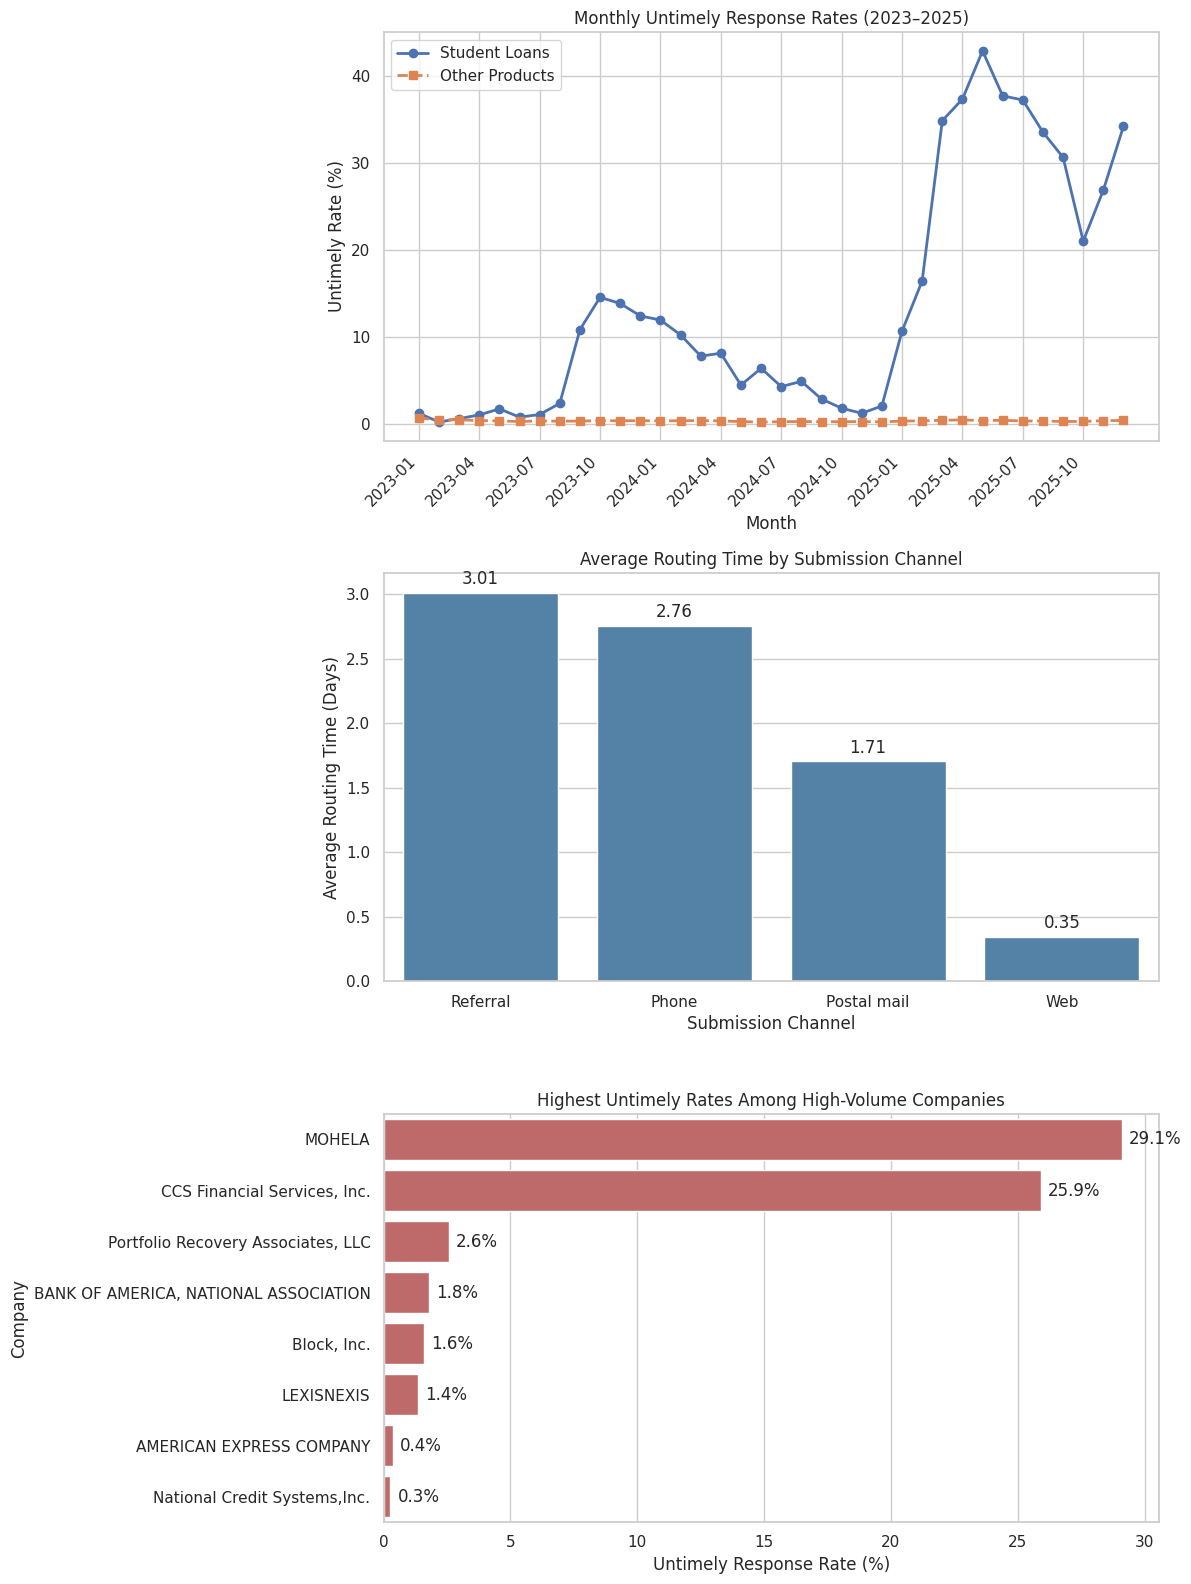

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(12, 16))
plt.subplots_adjust(hspace=0.4)


# 1. Monthly untimely response rates
plot_trend = monthly_trend.copy()
x_labels = [str(period) for period in plot_trend.index]

axes[0].plot(
    x_labels,
    plot_trend['Student_Loan_Untimely_Pct'],
    marker='o',
    linewidth=2,
    label='Student Loans'
)

axes[0].plot(
    x_labels,
    plot_trend['Other_Products_Untimely_Pct'],
    marker='s',
    linewidth=2,
    linestyle='--',
    label='Other Products'
)

axes[0].set_title('Monthly Untimely Response Rates (2023–2025)')
axes[0].set_ylabel('Untimely Rate (%)')
axes[0].set_xlabel('Month')
axes[0].legend()

axes[0].set_xticks(range(0, len(x_labels), 3))
axes[0].set_xticklabels(x_labels[::3], rotation=45, ha='right')


# 2. Average routing time by submission channel
main_channels = (
    channel_summary[channel_summary['Total_Complaints'] > 100]
    .reset_index()
)
main_channels['Submitted via'] = main_channels['Submitted via'].astype(str)
# Sort from longest routing delay to shortest
main_channels = main_channels.sort_values('Avg_Transit_Days', ascending=False)

sns.barplot(
    data=main_channels,
    x='Submitted via',
    y='Avg_Transit_Days',
    order=main_channels['Submitted via'],
    color='steelblue',
    ax=axes[1]
)

axes[1].set_title('Average Routing Time by Submission Channel')
axes[1].set_xlabel('Submission Channel')
axes[1].set_ylabel('Average Routing Time (Days)')

for bar in axes[1].patches:
    height = bar.get_height()
    axes[1].annotate(
        f'{height:.2f}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points'
    )


# 3. Companies with the highest untimely response rates
top_late = large_companies.head(8).reset_index()
top_late['Company'] = top_late['Company'].astype(str)

sns.barplot(
    data=top_late,
    y='Company',
    x='Untimely_Rate_Pct',
    color='indianred',
    ax=axes[2]
)

axes[2].set_title('Highest Untimely Rates Among High-Volume Companies')
axes[2].set_xlabel('Untimely Response Rate (%)')
axes[2].set_ylabel('Company')

for bar in axes[2].patches:
    width = bar.get_width()
    axes[2].annotate(
        f'{width:.1f}%',
        (width, bar.get_y() + bar.get_height() / 2),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points'
    )

plt.tight_layout()
plt.savefig('cfpb_bottlenecks_clean.png', dpi=300, bbox_inches='tight')
plt.show()

**6. Validation**

Verify the key metrics, response rates, routing times, and company-level comparisons to ensure the analysis results are consistent.

In [22]:
print("\n1. CLEANING IMPACT")
print(f"Rows before cleaning: {initial_rows:,}")
print(f"Rows after cleaning: {len(df_clean):,}")
print(f"Rows removed: {initial_rows - len(df_clean):,}")
print(f"Percentage removed: {(initial_rows - len(df_clean)) / initial_rows * 100:.2f}%")

print("\n2. UNTIMELY RESPONSE RATES")
print(f"Overall: {df_clean['Is_Untimely'].mean() * 100:.2f}%")

student_loans = df_clean[df_clean['Product'] == 'Student loan']
print(f"Student loans: {student_loans['Is_Untimely'].mean() * 100:.2f}%")

print("\n3. AVERAGE ROUTING TIME BY CHANNEL")
print(
    df_clean.groupby('Submitted via', observed=True)['Transit_Days']
    .mean().sort_values(ascending=False).round(2).to_string()
)

# Check selected high-volume companies
print("\n4. COMPANY UNTIMELY RATES")
for company in ['MOHELA', 'CCS Financial Services, Inc.']:
    company_rows = df_clean[
        df_clean['Company'].astype('string').str.strip().str.upper()
        == company.upper()
    ]
    if len(company_rows) > 0:
        rate = company_rows['Is_Untimely'].mean() * 100
        print(f"{company}: {rate:.2f}% ({len(company_rows):,} complaints)")
    else:
        print(f"{company}: No exact company-name match found")

# Response outcome shares among retained records
print("\n5. RESPONSE OUTCOME BREAKDOWN\n")
outcome_counts = df_clean['Outcome_Class'].value_counts()
outcome_pct = df_clean['Outcome_Class'].value_counts(normalize=True) * 100

outcome_summary = pd.DataFrame({
    'Count': outcome_counts,
    'Percentage': outcome_pct
})

print(outcome_summary.round(2).to_string())

print("\nValidation completed.")


1. CLEANING IMPACT
Rows before cleaning: 9,469,268
Rows after cleaning: 9,469,249
Rows removed: 19
Percentage removed: 0.00%

2. UNTIMELY RESPONSE RATES
Overall: 0.40%
Student loans: 17.58%

3. AVERAGE ROUTING TIME BY CHANNEL
Submitted via
Email          5.00
Referral       3.01
Phone          2.76
Postal mail    1.71
Web            0.35

4. COMPANY UNTIMELY RATES
MOHELA: 29.10% (20,932 complaints)
CCS Financial Services, Inc.: 25.92% (14,740 complaints)

5. RESPONSE OUTCOME BREAKDOWN

                           Count  Percentage
Outcome_Class                               
Explanation              5261385       55.56
Non-Monetary Relief      4125656       43.57
Monetary Relief            70225        0.74
Administrative/Untimely    11701        0.12
Administrative/Open          282        0.00

Validation completed.
